In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split

In [91]:
dataset= pd.read_csv("sonar_dataset.csv")
dataset[:5]

,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
0,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
1,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
2,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
3,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R
4,0.0286,0.0453,0.0277,0.0174,0.0384,0.0990,0.1201,0.1833,0.2105,0.3039,...,0.0045,0.0014,0.0038,0.0013,0.0089,0.0057,0.0027,0.0051,0.0062,R


In [92]:
dataset.groupby('R').describe()

0.0200                                                               0.0371  \
   count      mean       std     min      25%     50%      75%     max  count   
R                                                                               
M  111.0  0.034989  0.027074  0.0015  0.01795  0.0269  0.04185  0.1371  111.0   
R   96.0  0.022524  0.014762  0.0025  0.01220  0.0201  0.02915  0.0856   96.0   

             ...    0.0090         0.0032                                      \
       mean  ...       75%     max  count      mean       std     min     25%   
R            ...                                                                
M  0.045544  ...  0.011350  0.0364  111.0  0.006930  0.005958  0.0006  0.0031   
R  0.030232  ...  0.008675  0.0294   96.0  0.006053  0.003677  0.0011  0.0030   

                            
       50%     75%     max  
R                           
M  0.00530  0.0092  0.0439  
R  0.00545  0.0078  0.0180  

[2 rows x 480 columns]

In [93]:
dataset.R.value_counts()

R
M    111
R     96
Name: count, dtype: int64

In [94]:
dataset.dtypes

0.0200    float64
0.0371    float64
0.0428    float64
0.0207    float64
0.0954    float64
           ...   
0.0180    float64
0.0084    float64
0.0090    float64
0.0032    float64
R          object
Length: 61, dtype: object

In [95]:
len(dataset)

207

In [96]:
dataset.shape

(207, 61)

In [97]:
dataset['R']=dataset['R'].map({'R' : 0, 'M' : 1})

In [98]:
inputs=dataset.drop(['R'], axis= "columns")
target=dataset.R

In [99]:
X_train, X_test, y_train, y_test= train_test_split(inputs, target, test_size= 0.2, random_state= 42, stratify=target)
X_train= X_train.astype('float32')
X_test= X_test.astype('float32')
X_train.shape, X_test.shape

((165, 60), (42, 60))

In [100]:
ANN_model= keras.Sequential([
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid'),
])

ANN_model.compile(optimizer= 'adam',
                  loss= 'binary_crossentropy',
                  metrics= ['accuracy']
                 )

ANN_model.fit(X_train, y_train, epochs=30)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4848 - loss: 0.7118
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6970 - loss: 0.6760 
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6667 - loss: 0.6639 
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6909 - loss: 0.6444 
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7455 - loss: 0.6265 
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7636 - loss: 0.6042 
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7152 - loss: 0.5904 
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7939 - loss: 0.5540 
Epoch 9/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8000 - loss: 0.5307 
Epoch 10/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7697 - loss: 0.4999 
Epoch 11/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7818 - loss: 0.4803 
Epoch 12/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7515 - loss: 0.4839 
Ep

In [101]:
ANN_model.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7619 - loss: 0.4710 


[0.4709970951080322, 0.761904776096344]

In [102]:
from sklearn.metrics import classification_report, confusion_matrix

predictions= ANN_model.predict(X_test)
y_predict= (predictions >= 0.5).astype(int)

print(classification_report(y_test, y_predict))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
              precision    recall  f1-score   support

           0       0.70      0.84      0.76        19
           1       0.84      0.70      0.76        23

    accuracy                           0.76        42
   macro avg       0.77      0.77      0.76        42
weighted avg       0.78      0.76      0.76        42



In [103]:
cm= confusion_matrix(y_test, y_predict)
cm

array([[16,  3],
       [ 7, 16]])

<Axes: >

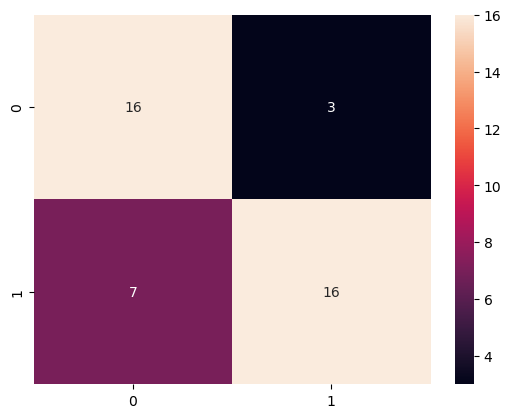

In [104]:
import seaborn as sn

plt.gray()
sn.heatmap(cm, annot=True)

In [105]:
ANN_model.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_72 (Dense)                     │ (None, 128)                 │           7,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_73 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_74 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_75 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 54,533 (213.02 KB)

 Trainable params: 18,177 (71.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 36,356 (142.02 KB)